Step1: Importing Required Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

Step2: Loading the Dataset

In [15]:
california = fetch_california_housing()

df = pd.DataFrame(california.data, columns=california.feature_names)

# Add the target variable (Median House Value in $100,000s)
df['MedHouseVal'] = california.target

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Step3: Separating Features and Target Variable

In [16]:
# X contains all features, y contains the target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

Step4: Train-Test Split

In [17]:
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (16512, 8)
Testing data shape: (4128, 8)


Step5: Feature Scaling

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Only transform the test data using the parameters learned from the training data
X_test_scaled = scaler.transform(X_test)

Step6: Training Multiple Models

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

trained_models = {}

# Training each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Ridge Regression trained successfully.
Decision Tree trained successfully.


Step7: Model Evaluation and Comparison

In [20]:
results = []

for name, model in trained_models.items():
    # Making predictions on the test set
    y_pred = model.predict(X_test_scaled)
    
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("\n--- Model Performance ---")
print(results_df.to_string(index=False))


--- Model Performance ---
            Model     RMSE  R2 Score
    Decision Tree 0.705987  0.619647
 Ridge Regression 0.745557  0.575816
Linear Regression 0.745581  0.575788


Lower RMSE indicates better prediction accuracy
Higher R^2 scores indicates better explanatory power

Step8: Visual Performance Validation

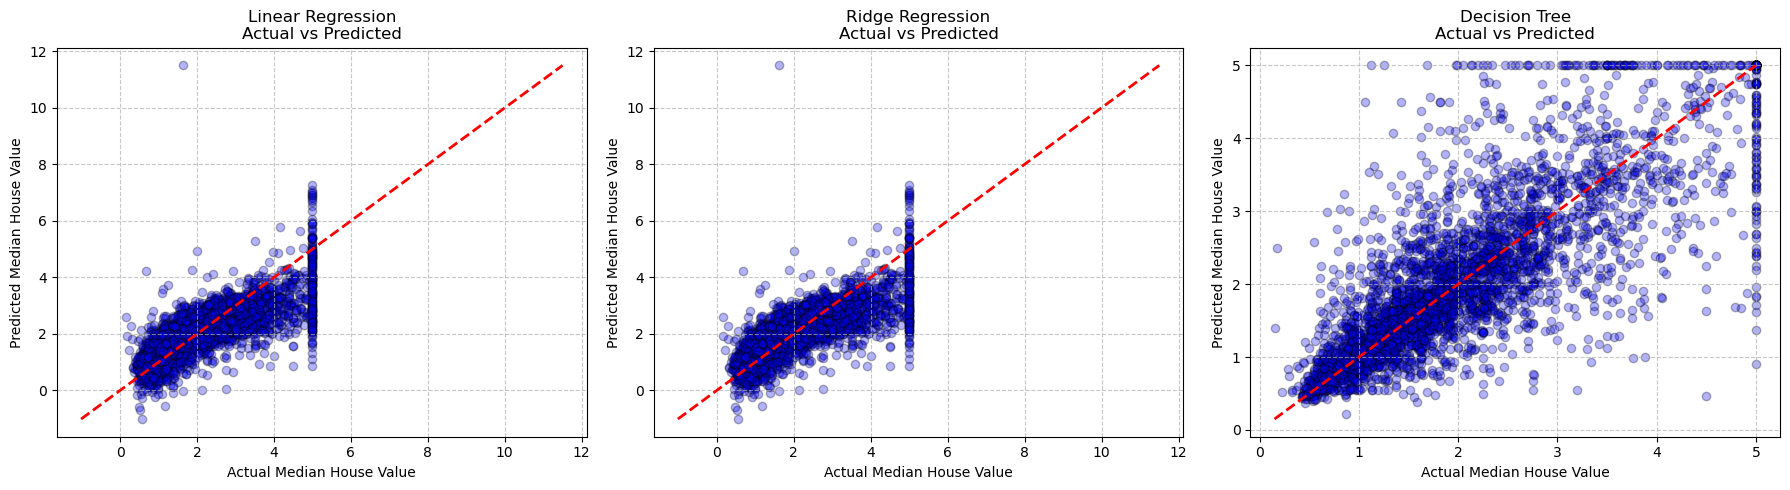

In [21]:
plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items(), 1):
    plt.subplot(1, 3, i)
    
    
    y_pred = model.predict(X_test_scaled)
    
    # Creating scatter plot
    plt.scatter(y_test, y_pred, alpha=0.3, color='blue', edgecolor='k')
    
    # Ploting the perfect prediction line (y = x)
    max_val = max(y_test.max(), y_pred.max())
    min_val = min(y_test.min(), y_pred.min())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    plt.title(f"{name}\nActual vs Predicted")
    plt.xlabel("Actual Median House Value")
    plt.ylabel("Predicted Median House Value")
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [22]:
print("\n=== Model Performance Comparison ===")
display_df = results_df.copy()

display_df['RMSE'] = display_df['RMSE'].round(4)
display_df['R2 Score'] = display_df['R2 Score'].round(4)

print(display_df.to_markdown(index=False))


=== Model Performance Comparison ===
| Model             |   RMSE |   R2 Score |
|:------------------|-------:|-----------:|
| Decision Tree     | 0.706  |     0.6196 |
| Ridge Regression  | 0.7456 |     0.5758 |
| Linear Regression | 0.7456 |     0.5758 |


In [23]:
import joblib

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\nThe best performing model is: {best_model_name}")

# Saving the model to a file
model_filename = 'best_california_housing_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Successfully saved {best_model_name} to '{model_filename}'")



The best performing model is: Decision Tree
Successfully saved Decision Tree to 'best_california_housing_model.pkl'


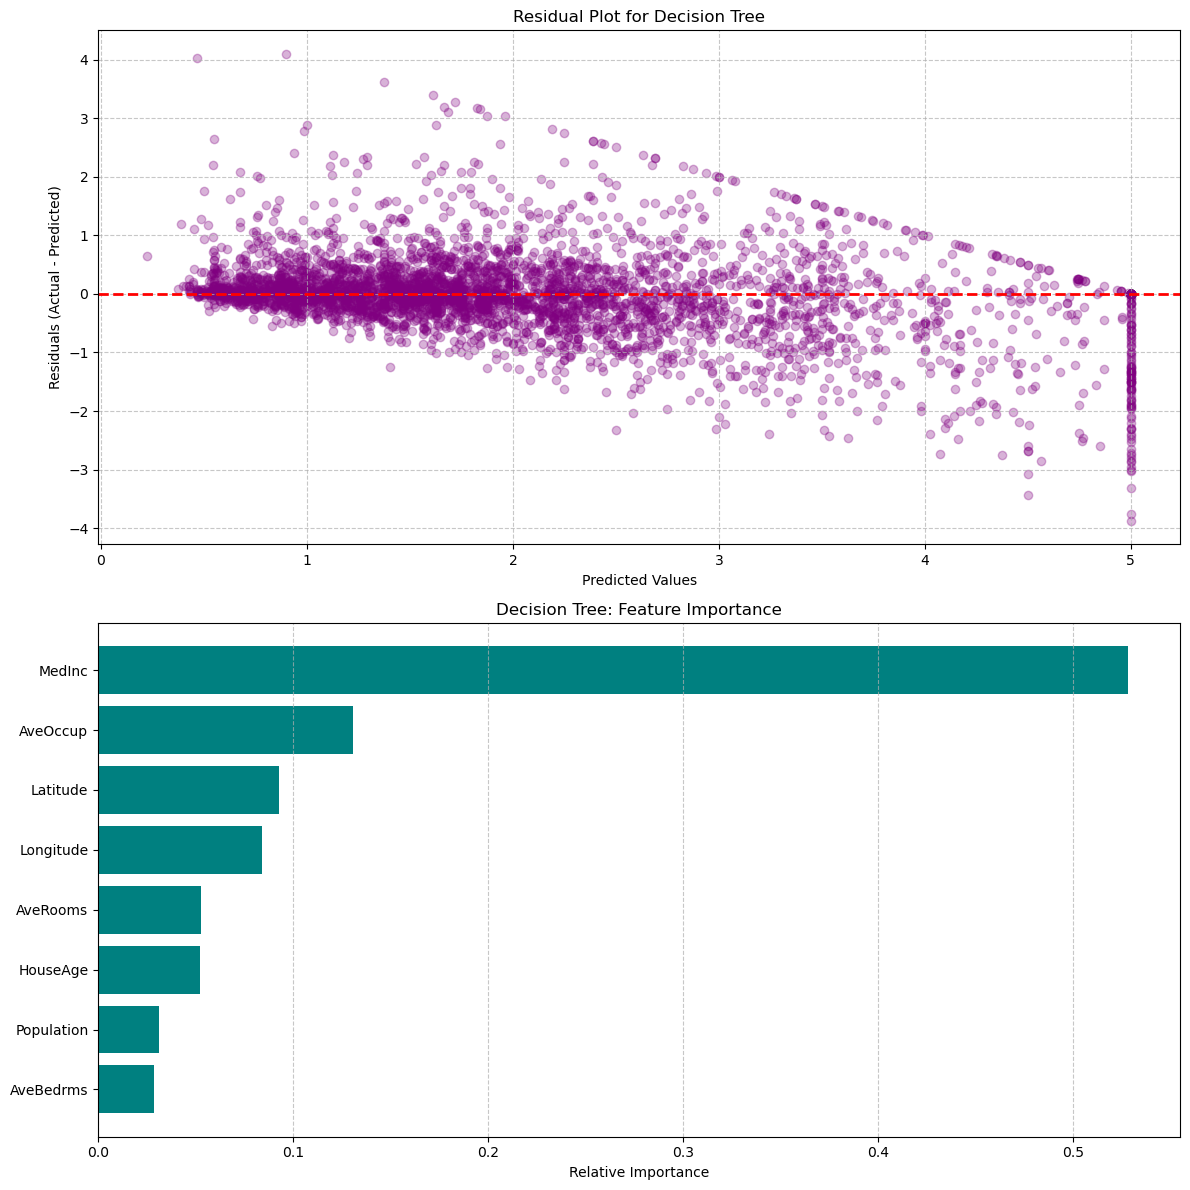

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# --- Insight 1: Residual Plot for the Best Model ---
# Calculate residuals: Actual - Predicted
y_pred_best = best_model.predict(X_test_scaled)
residuals = y_test - y_pred_best

axes[0].scatter(y_pred_best, residuals, alpha=0.3, color='purple')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_title(f"Residual Plot for {best_model_name}")
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals (Actual - Predicted)")
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- Insight 2: Feature Importance (Decision Tree) ---
# Extracting feature importances from the Decision Tree
dt_model = trained_models["Decision Tree"]
importances = dt_model.feature_importances_

# Sorting features by importance
indices = np.argsort(importances)
features = X.columns

axes[1].barh(range(len(indices)), importances[indices], color='teal', align='center')
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([features[i] for i in indices])
axes[1].set_title("Decision Tree: Feature Importance")
axes[1].set_xlabel("Relative Importance")
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()